In [1]:
from nilearn import datasets
import nilearn
from nilearn.plotting import plot_roi, show
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import input_data

import numpy as np
from nilearn import plotting

/tmp/ipykernel_70150/2626990669.py:7: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import input_data


In [2]:
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [3]:
xcpd_nodes = pd.read_csv('xcpd_problematic_nodes.tsv', sep='\t')['index'].values

In [4]:
msmall_nodes = pd.read_csv('msmall_problematic_nodes.tsv', sep='\t')['index'].values

In [5]:
atlas_file = schaefer['maps']

atlas = nib.load(atlas_file) 

In [6]:
sum(sum(atlas.get_fdata() == 100)) 

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  51,  54,  78,  90, 100,
       105, 127, 142, 150, 184, 193, 227, 263, 296, 331, 349, 354, 386,
       390, 395, 396, 389, 388, 380, 334, 259, 182,  79,  25,  18,   9,
         2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [7]:
atlas_labels = schaefer['labels']

In [9]:
xcpd_node_df = pd.read_csv('xcpd_node_r2.csv', index_col='node')

xcpd_node_df.rename(columns={'0': 'r2'}, inplace=True)

In [10]:
# xcpd_node_df.index= [ii.replace('node_', '') for ii in xcpd_node_df.index ] 

In [11]:
node_list = np.array(xcpd_node_df.index)

In [12]:
node_list = np.array(node_list) 

In [13]:
xcpd_nodes

array([31, 32, 42, 51, 79, 80, 94])

In [14]:
dir(schaefer) 

['atlas_type', 'description', 'labels', 'lut', 'maps', 'template']

In [15]:
atlas.get_fdata().max() 

np.float64(100.0)

In [16]:
atlas = nib.load(atlas_file) 
xcpd_atlas = atlas.get_fdata()

for ii in node_list: 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        xcpd_atlas[np.isin(nilearn.image.get_data(atlas),
                           (int(ii.replace('node_', '')) + 1)) ] = xcpd_node_df['r2'].loc[ii]

#xcpd_atlas[!np.isin(nilearn.image.get_data(atlas), node_list)] = xcpd_node_df['r2'].iloc[ii]

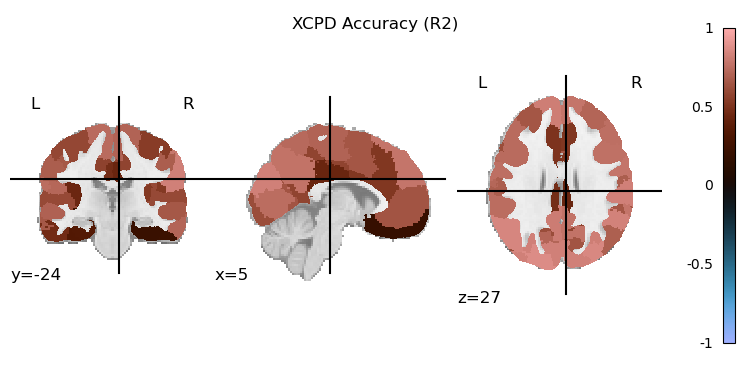

In [17]:
mask_img = nilearn.image.new_img_like(atlas, xcpd_atlas)

mask_img.to_filename('xcpd_prob_nodes.nii.gz') 
plotting.plot_stat_map(
mask_img,vmax=1, vmin=-1, cmap='berlin' )  
plt.suptitle('XCPD Accuracy (R2)') 
plotting.show()



In [18]:
xcpd_atlas[np.isin(nilearn.image.get_data(atlas),np.array(xcpd_node_df.index, dtype=int))] = xcpd_node_df['r2'] 
xcpd_atlas[~np.isin(nilearn.image.get_data(atlas), np.array(xcpd_node_df.index, dtype=int))] = 0

ValueError: invalid literal for int() with base 10: 'node_30'

In [ ]:
atlas = nib.load(atlas_file) 
msmall_atlas = atlas.get_fdata() 

In [ ]:
# msmall_atlas[np.isin(nilearn.image.get_data(atlas), msmall_nodes)] = msmall_atlas[np.isin(nilearn.image.get_data(atlas), msmall_nodes)] 
msmall_atlas[~np.isin(nilearn.image.get_data(atlas), msmall_nodes)] = 0

In [ ]:
mask_img = nilearn.image.new_img_like(atlas, xcpd_atlas)
plotting.plot_roi(
mask_img, cmap=schaefer.lut.iloc[xcpd_nodes])  
plt.suptitle('XCPD Problematic Nodes') 

mask_img.to_filename('xcpd_prob_nodes.nii.gz') 

In [ ]:
mask_img = nilearn.image.new_img_like(atlas, msmall_atlas)
plotting.plot_roi(
mask_img, cmap=schaefer.lut.iloc[msmall_nodes])  
plt.suptitle('MSMALL Problematic Nodes') 
mask_img.to_filename('msmall_problematic_nodes.nii.gz') 

In [ ]:
schaefer.lut.iloc[msmall_nodes]